x=0.000000, y=0.000000, r=0.125000, psi=4.444444


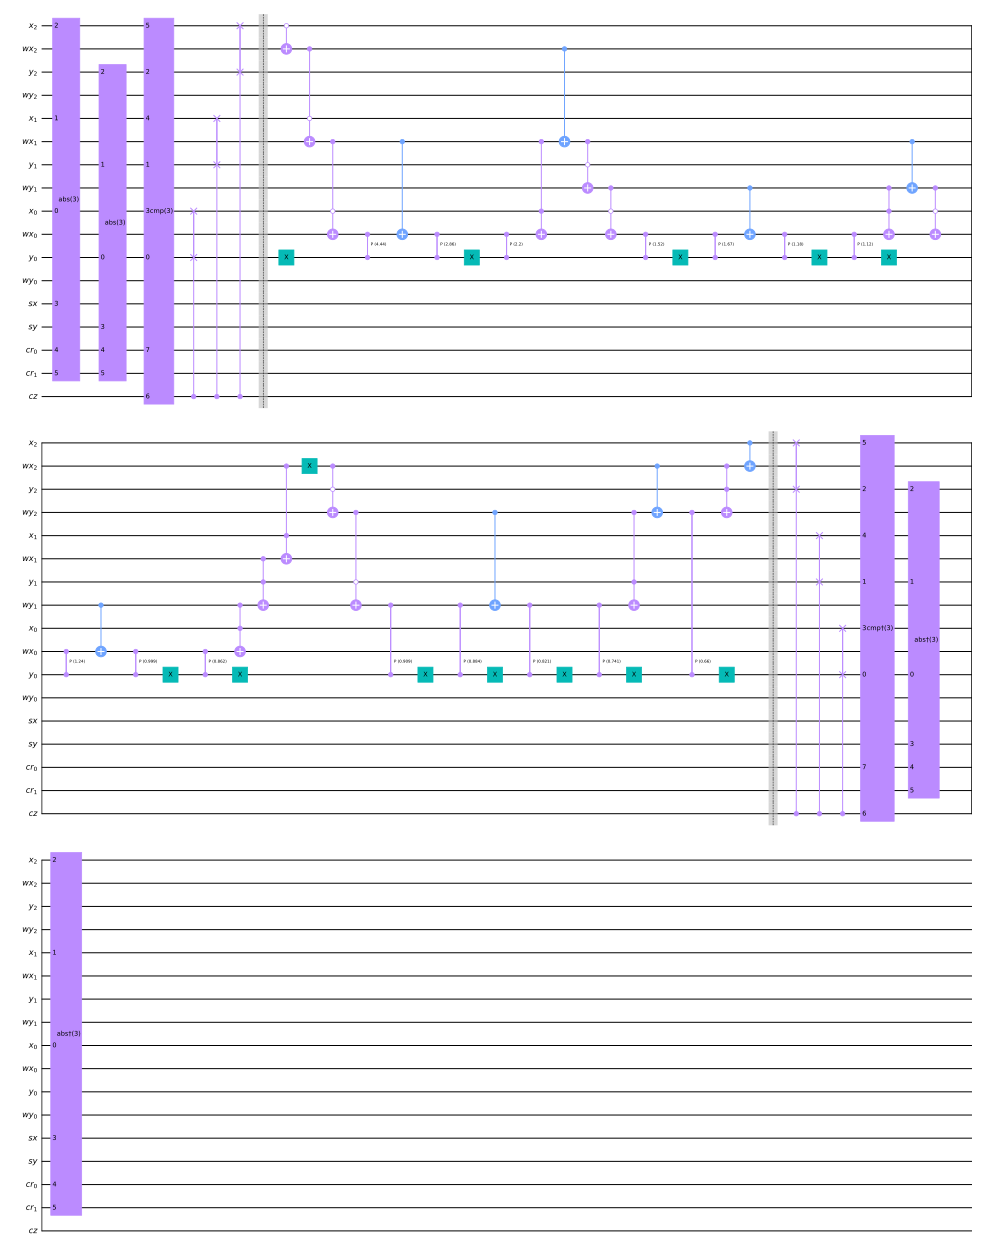

In [1]:
from crsq.blocks.radial_func_qrom import RadialFuncQrom

def coulomb(r):
    return 1/(r+0.1)
n=3
L=1.0
dq = L/2**(n-1)

rfq = RadialFuncQrom(n, dq, coulomb)

rfq.circuit.draw(filename="output/diagrams/rfqrom-circuit-n3.png", scale=0.5, fold=40,  wire_order=rfq.regs)

has_data_y[0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0

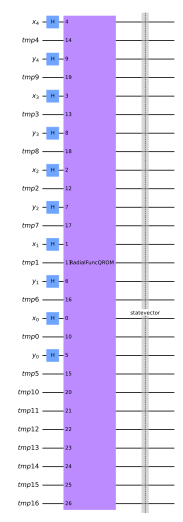

In [9]:
from crsq.blocks.radial_func_qrom import RadialFuncQromTestBoard
from qiskit_aer import AerSimulator
from qiskit import transpile
import crsq.utils.statevector as stv
import matplotlib.pyplot as plt
import math

def coulomb(r):
    # return math.exp(-r**2)
    return 1/(r+0.5)

n=5
dq = 1/(2**(n-1))

tb = RadialFuncQromTestBoard(n, dq, coulomb)
qc = tb.circuit
qc.save_statevector()
qc.draw(scale=0.4, fold=40,  wire_order=tb.regs)

In [10]:
from crsq.blocks.radial_func_qrom import RadialFuncQromTestBoard
from qiskit_aer import AerSimulator
from qiskit import transpile
import crsq.utils.statevector as stv
import matplotlib.pyplot as plt
import math

def draw_graph(rfunc, name):
    n=5
    dq = 1/2**(n-1)

    tb = RadialFuncQromTestBoard(n, dq, rfunc)
    qc = tb.circuit
    qc.save_statevector()
    # qc.draw(scale=0.4, fold=40,  wire_order=tb.regs)
    backend = AerSimulator()
    tp = transpile(qc, backend)
    result = backend.run(tp).result()

    sv = result.get_statevector()
    (x, y, z, dz) = stv.extract_arithmetic_result_2dphase_bars(tb, sv, tb._x, tb._y)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.view_init(elev=20, azim=50)
    ax.set(xlabel='X',ylabel='Y',zlabel='X-Y')

    ax.bar3d(x, y, z, 1, 1, dz, shade=True)
    # fig.savefig("output/diagrams/rfqrom-n5.png")
    fig.savefig(f"output/diagrams/rfqrom-n5-{name}.png")
    plt.show()


has_data_y[0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0

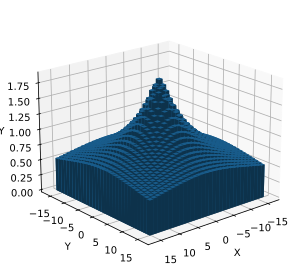

In [11]:
def coulomb(r):
    return 1/(r+0.5)

draw_graph(coulomb, "coulomb")

has_data_y[0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0

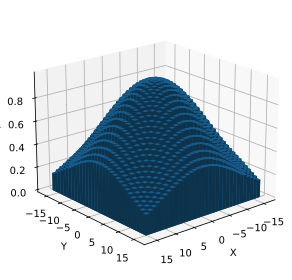

In [12]:
def gaussian(r):
    return math.exp(-r**2)
    # return 1/(r+0.5)

draw_graph(gaussian, "gaussian")

# RFQ Hamiltonian

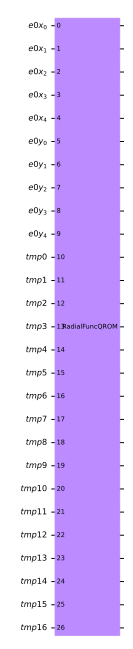

In [13]:
from crsq.blocks import(wave_function, hamiltonian, discretization, rfqhamiltonian)
n =5
wfr_spec = wave_function.WaveFunctionRegisterSpec(
    dimension=2,
    num_coordinate_bits=n,
    space_length=32,
    num_electrons=1,
    num_moving_nuclei=0,
    num_stationary_nuclei=1,
)
ham_spec = hamiltonian.HamiltonianSpec(
    wfr_spec, nuclei_data=[{"charge": 1, "pos": [0, 0]}]
)
def rfunc_for_rfqh(r):
    return 1/(r+0.5)
rfunc = rfunc_for_rfqh
rfq_spec = rfqhamiltonian.RfqPotentialSpec(wfr_spec, rfunc, rfunc)
delta_t=1e-3
disc_spec = discretization.DiscretizationSpec(delta_t)
repb = rfqhamiltonian.RfqElectronPotentialBlock(rfq_spec, ham_spec, disc_spec)
repb.circuit.draw(filename="output/diagrams/rfqham-circuit-n5.png", scale=0.5, fold=40)

# count gates

In [14]:
import re
from crsq.blocks import (
    wave_function,
    hamiltonian,
    discretization,
    rfqhamiltonian,
    radial_func_qrom,
)

def decompose_circuit_to_privmities(circuit):
    while True:
        ops = circuit.count_ops()
        cnames = []
        for op in ops:
            # print(f"op: [{op}]")
            m = re.search('circuit|adder|subtractor|square|sqrt|divide|UMA|MAJ', op)
            if m :
                cnames.append(op)
        if len(cnames) == 0:
            return circuit
        # print(f"decompose with {cnames}")
        qc = circuit.decompose(cnames)
        circuit = qc

def rfunc_for_rfq(r):
    return r

def count_gate_rfq(n):
    dq = 1 / 2 ** (n - 1)
    tb = radial_func_qrom.RadialFuncQrom(n, dq, rfunc_for_rfq, verbose=False)
    qc = decompose_circuit_to_privmities(tb.circuit)
    ops = qc.count_ops()
    print(f"n:{n}  rfq count_ops:{ops}")
    return qc

# count_gates_and_save_as_csv(5, 8, count_gate_rfq, "rfqrom")
def rfunc_for_rfqh(r):
    return 1/(r+0.5)

def count_gate_rfqhamiltonian(n):
    wfr_spec = wave_function.WaveFunctionRegisterSpec(
        dimension=2,
        num_coordinate_bits=n,
        space_length=32,
        num_electrons=1,
        num_moving_nuclei=0,
        num_stationary_nuclei=1,
    )
    ham_spec = hamiltonian.HamiltonianSpec(
        wfr_spec, nuclei_data=[{"charge": 1, "pos": [0, 0]}]
    )
    rfunc = rfunc_for_rfqh
    rfq_spec = rfqhamiltonian.RfqPotentialSpec(wfr_spec, rfunc, rfunc)
    delta_t=1e-3
    disc_spec = discretization.DiscretizationSpec(delta_t)
    repb = rfqhamiltonian.RfqElectronPotentialBlock(rfq_spec, ham_spec, disc_spec)
    qc = decompose_circuit_to_privmities(repb.circuit)
    ops = qc.count_ops()
    print(f"n:{n}  rfqhamiltonian count_ops:{ops}")
    return qc

def count_gate_arithmetic_elec_potential(n):
    wfr_spec = wave_function.WaveFunctionRegisterSpec(
        dimension=2,
        num_coordinate_bits=n,
        space_length=32,
        num_electrons=1,
        num_moving_nuclei=0,
        num_stationary_nuclei=1,
    )
    ham_spec = hamiltonian.HamiltonianSpec(
        wfr_spec, nuclei_data=[{"charge": 1, "pos": (0, 0)}]
    )
    delta_t=1e-3
    disc_spec = discretization.DiscretizationSpec(delta_t)
    epb = hamiltonian.ElectronPotentialBlock(ham_spec, disc_spec)
    qc = decompose_circuit_to_privmities(epb.circuit)
    ops = qc.count_ops()
    print(f"n:{n}  Arithmetic Hamiltonian count_ops:{ops}")
    return qc


def count_gates_and_save_as_csv(N0, N, count_gate_func, label):
    filename = f"output/rfqrom-gatecount-{label}-{N0}-{N}.csv"
    oplist = []
    for n in range(N0, N+1):
        qc = count_gate_func(n)
        width = qc.width()
        odict = qc.count_ops()
        odict["n"] = n
        odict["width"] = width
        oplist.append(odict)
    cols0 = [
        "n",
        "width",
        "mcx",
        "ccx",
        "ccx_o1",
        "cswap",
        "cx",
        "cx_o0",
        "cp",
        "cu",
        "x",
        "h",
        "u",
        "p",
    ]
    cols = [col for col in cols0 if col in oplist[0]]
    with open(filename, "w") as f:
        f.write(",".join(cols) + "\n")
        for op in oplist:
            f.write(",".join([str(op[col]) for col in cols]) + "\n")

# count_gate_arithmetic_elec_potential(5)

count_gates_min = 5
count_gates_max = 8
count_gates_and_save_as_csv(count_gates_min, count_gates_max, count_gate_arithmetic_elec_potential, "arith-elec-potential")

#count_gates_and_save_as_csv(5, 12, count_gate_rfqhamiltonian, "rfqrom")

n:5  Arithmetic Hamiltonian count_ops:OrderedDict([('cx', 3722), ('u', 2492), ('ccx', 2124), ('cu', 356), ('x', 182), ('p', 106), ('mcx', 32)])
n:6  Arithmetic Hamiltonian count_ops:OrderedDict([('cx', 5046), ('u', 3332), ('ccx', 2882), ('cu', 476), ('x', 242), ('p', 139), ('mcx', 50)])
n:7  Arithmetic Hamiltonian count_ops:OrderedDict([('cx', 6544), ('u', 4284), ('ccx', 3746), ('cu', 612), ('x', 310), ('p', 176), ('mcx', 72)])
n:8  Arithmetic Hamiltonian count_ops:OrderedDict([('cx', 8232), ('u', 5348), ('ccx', 4716), ('cu', 764), ('x', 386), ('p', 217), ('mcx', 98)])
